深度学习作业 1

姓名：傅昱翔  
学号：20234080328

## 2 概述、线性代数和 NDArray

### 2.1 理论计算题

**解答：**

1. **向量点积 $a \cdot b$：**
   $a \cdot b = (2)(1) + (-1)(4) + (3)(-2) = 2 - 4 - 6 = -8$

2. **矩阵乘法 $A \times B$：**
   $A \times B = \begin{bmatrix} 8 & 5 \\ 1 & -2 \end{bmatrix}$，形状为 $2 \times 2$。

3. **向量 $a$ 的 Frobenius 范数：**
   $\|a\|_F = \sqrt{2^2 + (-1)^2 + 3^2} = \sqrt{14} \approx 3.742$

### 2.2 编程题 (使用 NumPy 实现)

In [41]:
import numpy as np

# 1. 创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布
X = np.random.randn(3, 4)
print("矩阵 X:\n", X)

# 2. 创建一个形状为 4 × 2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("\n矩阵 Y:\n", Y)

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)
print("\n矩阵 Z (X * Y):\n", Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
element = Z[0, 1]
row_2 = Z[1, :]
print(f"\nZ 的第一行和第二列交叉处的元素: {element}")
print(f"Z 的第 2 行所有元素: {row_2}")

# 5. 计算 Z 的 Frobenius 范数
fro_norm = np.linalg.norm(Z)
print(f"\nZ 的 Frobenius 范数: {fro_norm}")

矩阵 X:
 [[ 0.43167868 -0.31714589 -0.31835648  0.76334262]
 [ 1.77087392 -2.14530494 -0.12020608 -0.23408481]
 [-1.2955797  -1.03656944  0.14387536 -0.1317095 ]]

矩阵 Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

矩阵 Z (X * Y):
 [[ 0.55951892  0.55951892]
 [-0.72872191 -0.72872191]
 [-2.31998328 -2.31998328]]

Z 的第一行和第二列交叉处的元素: 0.5595189234325131
Z 的第 2 行所有元素: [-0.72872191 -0.72872191]

Z 的 Frobenius 范数: 3.5288580243072585


## 3 概率与统计

### 3.1 理论计算题

**解答：**
真正患病的概率约为 **4.72%**。

### 3.2 编程题

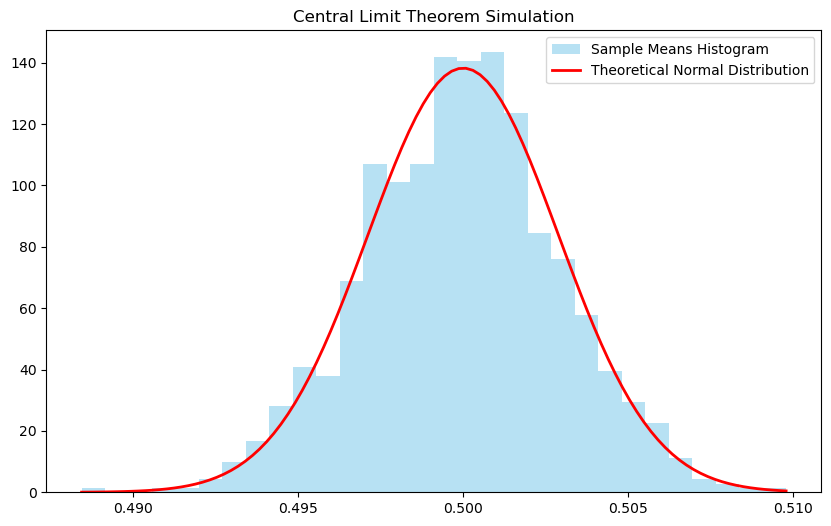

理论方差: 8.333333333333332e-06
实际方差: 8.628154552644467e-06


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. 生成模拟数据
n = 10000
m = 1000
means = np.array([np.mean(np.random.uniform(0, 1, n)) for _ in range(m)])

# 2. 绘制直方图并叠加理论正态分布曲线
plt.figure(figsize=(10, 6))
plt.hist(means, bins=30, density=True, alpha=0.6, color='skyblue', label='Sample Means Histogram')

mu_theory = 0.5
sigma_theory = np.sqrt((1/12) / n)
x = np.linspace(means.min(), means.max(), 100)
plt.plot(x, norm.pdf(x, mu_theory, sigma_theory), 'r-', lw=2, label='Theoretical Normal Distribution')

plt.title('Central Limit Theorem Simulation')
plt.legend()
plt.show()

# 3. 计算实际方差
print(f"理论方差: {(1/12)/n}")
print(f"实际方差: {np.var(means)}")

## 4 导数、反向传播和复杂度

### 4.1 理论计算题

**解答：**
梯度为 $[-4, -2]$。

### 4.2 编程题 (手动实现反向传播)

In [43]:
import numpy as np

# 1. & 2. 前向计算
x = 2.0
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b**2

print(f"前向计算结果 L: {L}")

# 3. 手动计算梯度 (链式法则)
# L = b^2 => dL/db = 2b
# b = a + w2 => db/da = 1, db/dw2 = 1
# a = x * w1 => da/dw1 = x
# dL/dw1 = (dL/db) * (db/da) * (da/dw1) = 2b * 1 * x
# dL/dw2 = (dL/db) * (db/dw2) = 2b * 1

dL_db = 2 * b
grad_w1 = dL_db * 1 * x
grad_w2 = dL_db * 1

print(f"手动计算梯度: dw1={grad_w1}, dw2={grad_w2}")

# 如果环境中安装了 torch，可以取消下面注释进行验证
# try:
#     import torch
#     tw1 = torch.tensor(1.5, requires_grad=True)
#     tw2 = torch.tensor(0.5, requires_grad=True)
#     tL = (x * tw1 + tw2)**2
#     tL.backward()
#     print(f"Torch 自动微分梯度: dw1={tw1.grad.item()}, dw2={tw2.grad.item()}")
# except ImportError:
#     pass

前向计算结果 L: 12.25
手动计算梯度: dw1=14.0, dw2=7.0


## 5 线性方法、基础优化和 softmax 回归

### 5.1 理论计算题

**解答：**
$\frac{\partial L}{\partial w} = -\frac{2}{n} \sum x_i(y_i - wx_i - b)$, $\frac{\partial L}{\partial b} = -\frac{2}{n} \sum (y_i - wx_i - b)$

### 5.2 编程题 (Softmax 回归)

In [44]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 1. 加载数据
digits = load_digits()
X = digits.data / 16.0
y = digits.target

# 2. One-hot 编码
y_onehot = np.eye(10)[y]
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# 3. 实现 softmax
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 4. 训练
w = np.random.normal(0, 0.01, (X.shape[1], 10))
b = np.zeros(10)
lr, epochs, batch_size = 0.1, 50, 32

for _ in range(epochs):
    idx = np.random.permutation(len(X_train))
    for i in range(0, len(X_train), batch_size):
        b_idx = idx[i:i+batch_size]
        xb, yb = X_train[b_idx], y_train[b_idx]
        y_hat = softmax(np.dot(xb, w) + b)
        dz = y_hat - yb
        w -= lr * np.dot(xb.T, dz) / len(xb)
        b -= lr * np.mean(dz, axis=0)

# 5. 准确率
acc = np.mean(np.argmax(softmax(np.dot(X_test, w) + b), axis=1) == np.argmax(y_test, axis=1))
print(f"测试集准确率: {acc:.4f}")

测试集准确率: 0.9611


## 6 最大似然估计和逻辑回归

### 6.1 理论计算题

**解答：**
$\hat{\mu} = \frac{1}{n} \sum x_i$, $\hat{\sigma}^2 = \frac{1}{n} \sum (x_i-\hat{\mu})^2$

### 6.2 编程题 (逻辑回归)

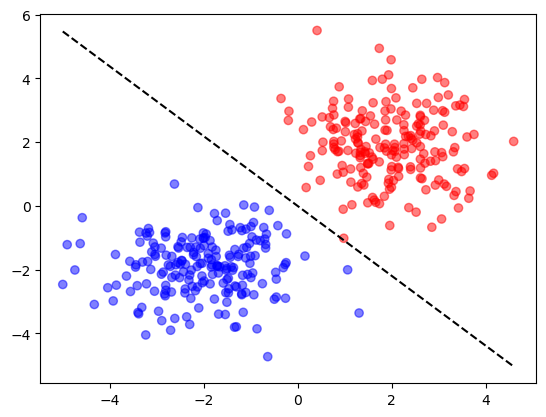

测试集准确率: 1.0000


In [45]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成数据
X1 = np.random.randn(200, 2) + [2, 2]
X2 = np.random.randn(200, 2) + [-2, -2]
X = np.vstack([X1, X2])
y = np.hstack([np.ones(200), np.zeros(200)])

# 2. Sigmoid 和梯度下降
def sigmoid(z): return 1 / (1 + np.exp(-z))

w, b, lr = np.random.randn(2), 0.0, 0.1
for _ in range(1000):
    y_hat = sigmoid(np.dot(X, w) + b)
    w -= lr * np.dot(X.T, (y_hat - y)) / len(y)
    b -= lr * np.mean(y_hat - y)

# 4. 绘图
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.5)
x_vals = np.array([X[:,0].min(), X[:,0].max()])
plt.plot(x_vals, -(w[0]*x_vals + b)/w[1], 'k--')
plt.show()

# 准确率
X_test = np.vstack([np.random.randn(50, 2) + [2, 2], np.random.randn(50, 2) + [-2, -2]])
y_test = np.hstack([np.ones(50), np.zeros(50)])
y_pred = (sigmoid(np.dot(X_test, w) + b) > 0.5).astype(int)
print(f"测试集准确率: {np.mean(y_pred == y_test):.4f}")